In [1]:
! pip install ISLP

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 546.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.0/522.0 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.2/815.2 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 890.6/890.6 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.5/94.5 kB 5.9 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4031 sha256=8ee183fc3958b3ccf5052eabd99e2ff53023c3e90f874686d225ab8eba29c9e4
  Stored in directory: /root/.cache/pip/wheels/25/cc/e0/ef2969164144c899fedb22b338f6703e2b9cf46eeebf254991
Successfully built autograd-gamma
  Attempting 

**Solution of Ques 14 (a) Create a binary variable mpg01:**

In [22]:
import pandas as pd

# Load the dataset
url = 'https://www.statlearning.com/s/Auto.csv'
auto = pd.read_csv(url)

# Remove any potential whitespace from column names
auto.columns = auto.columns.str.strip()
# Convert horsepower to numeric, setting errors='coerce' to handle any non-numeric values.
auto['horsepower'] = pd.to_numeric(auto['horsepower'], errors='coerce')
# Create the binary variable
auto['mpg01'] = (auto['mpg'] > auto['mpg'].median()).astype(int)

# Display the first few rows to verify
print(auto.head())
# Display the last few rows
print(auto.tail())

    mpg  cylinders  displacement  horsepower  weight  acceleration  year  \
0  18.0          8         307.0       130.0    3504          12.0    70   
1  15.0          8         350.0       165.0    3693          11.5    70   
2  18.0          8         318.0       150.0    3436          11.0    70   
3  16.0          8         304.0       150.0    3433          12.0    70   
4  17.0          8         302.0       140.0    3449          10.5    70   

   origin                       name  mpg01  
0       1  chevrolet chevelle malibu      0  
1       1          buick skylark 320      0  
2       1         plymouth satellite      0  
3       1              amc rebel sst      0  
4       1                ford torino      0  
      mpg  cylinders  displacement  horsepower  weight  acceleration  year  \
392  27.0          4         140.0        86.0    2790          15.6    82   
393  44.0          4          97.0        52.0    2130          24.6    82   
394  32.0          4         135.

(b) Explore the data graphically in order to investigate the association between mpg01 and the other features. Which of the other
features seem most likely to be useful in predicting mpg01? Scatterplots and boxplots may be useful tools to answer this question. Describe your fndings.

In [23]:
import statsmodels.api as sm
from ISLP import load_data
from ISLP import confusion_table
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis as LDA, QuadraticDiscriminantAnalysis as QDA)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from ISLP.models import ModelSpec as MS
auto.corr(numeric_only=True)

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,mpg01
mpg,1.000000,-0.776260,-0.804443,-0.778427,-0.831739,0.422297,0.581469,0.563698,0.838239
cylinders,-0.776260,1.000000,0.950920,0.842983,0.897017,-0.504061,-0.346717,-0.564972,-0.740327
displacement,-0.804443,0.950920,1.000000,0.897257,0.933104,-0.544162,-0.369804,-0.610664,-0.738607
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171,-0.649259
weight,-0.831739,0.897017,0.933104,0.864538,1.000000,-0.419502,-0.307900,-0.581265,-0.745734
acceleration,0.422297,-0.504061,-0.544162,-0.689196,-0.419502,1.000000,0.282901,0.210084,0.322629
year,0.581469,-0.346717,-0.369804,-0.416361,-0.307900,0.282901,1.000000,0.184314,0.454108
origin,0.563698,-0.564972,-0.610664,-0.455171,-0.581265,0.210084,0.184314,1.000000,0.511393
mpg01,0.838239,-0.740327,-0.738607,-0.649259,-0.745734,0.322629,0.454108,0.511393,1.000000


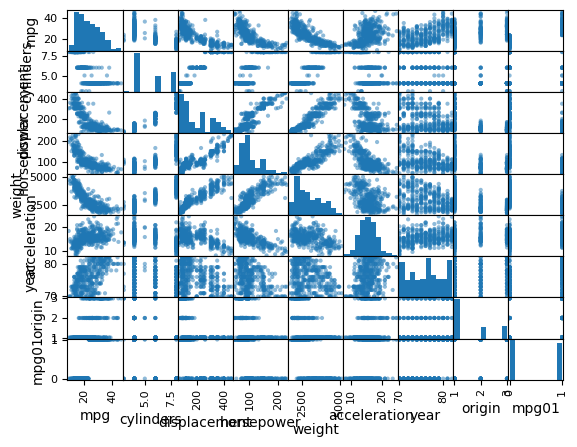

In [24]:
import seaborn as sns
pd.plotting.scatter_matrix(auto);

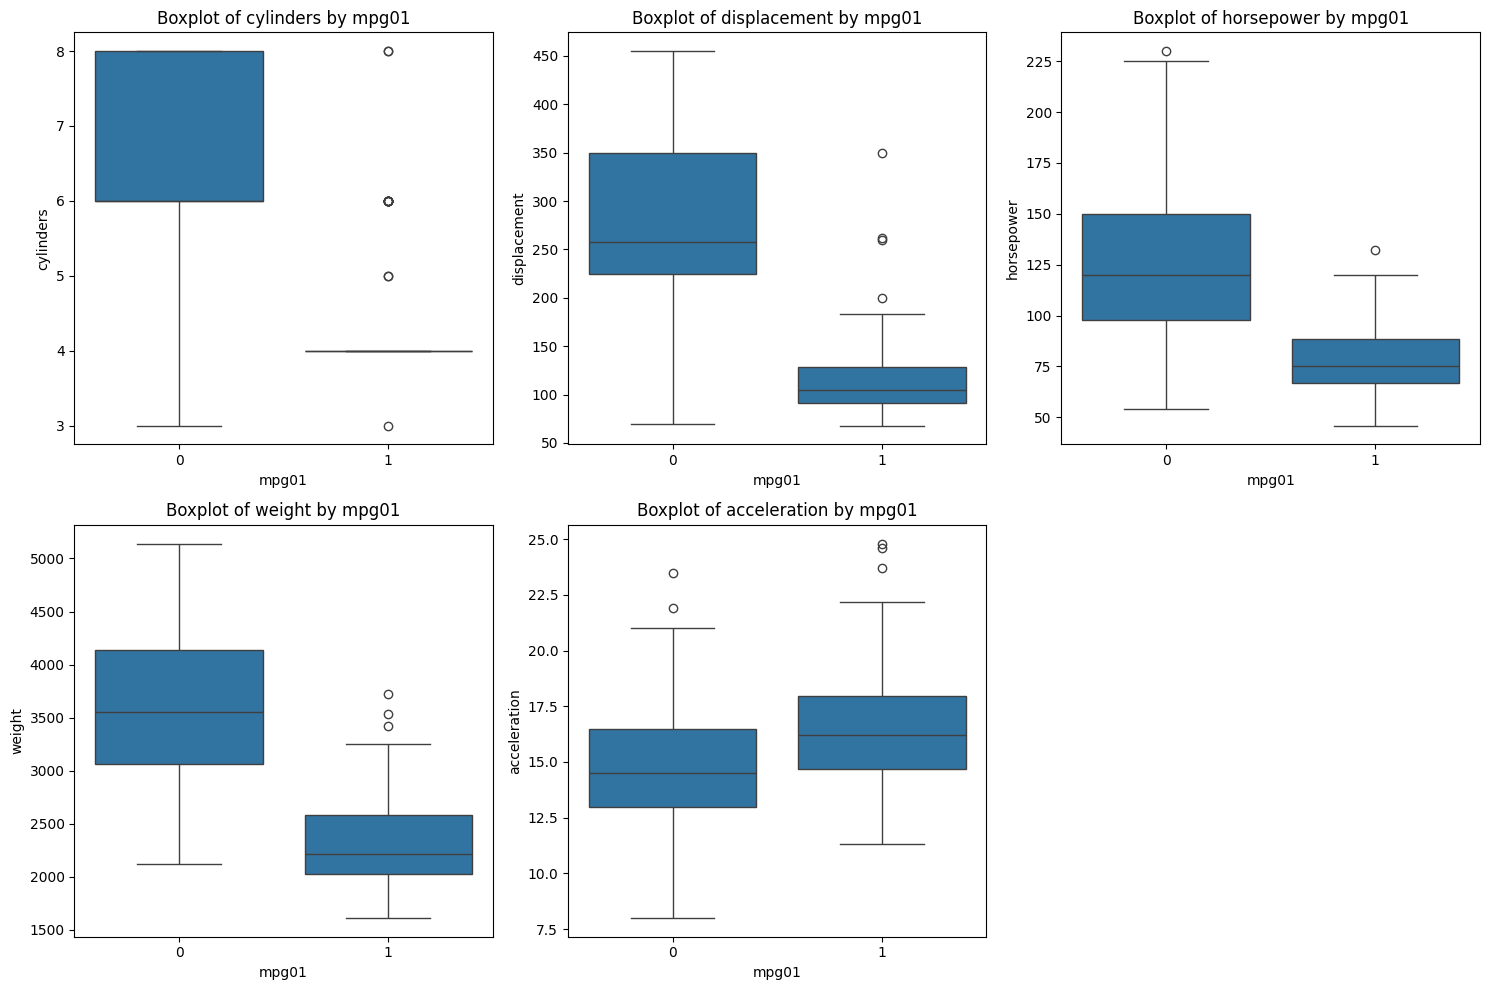

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create boxplots for each feature
features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']

plt.figure(figsize=(15, 10))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='mpg01', y=feature, data=auto)
    plt.title(f'Boxplot of {feature} by mpg01')

plt.tight_layout()
plt.show()


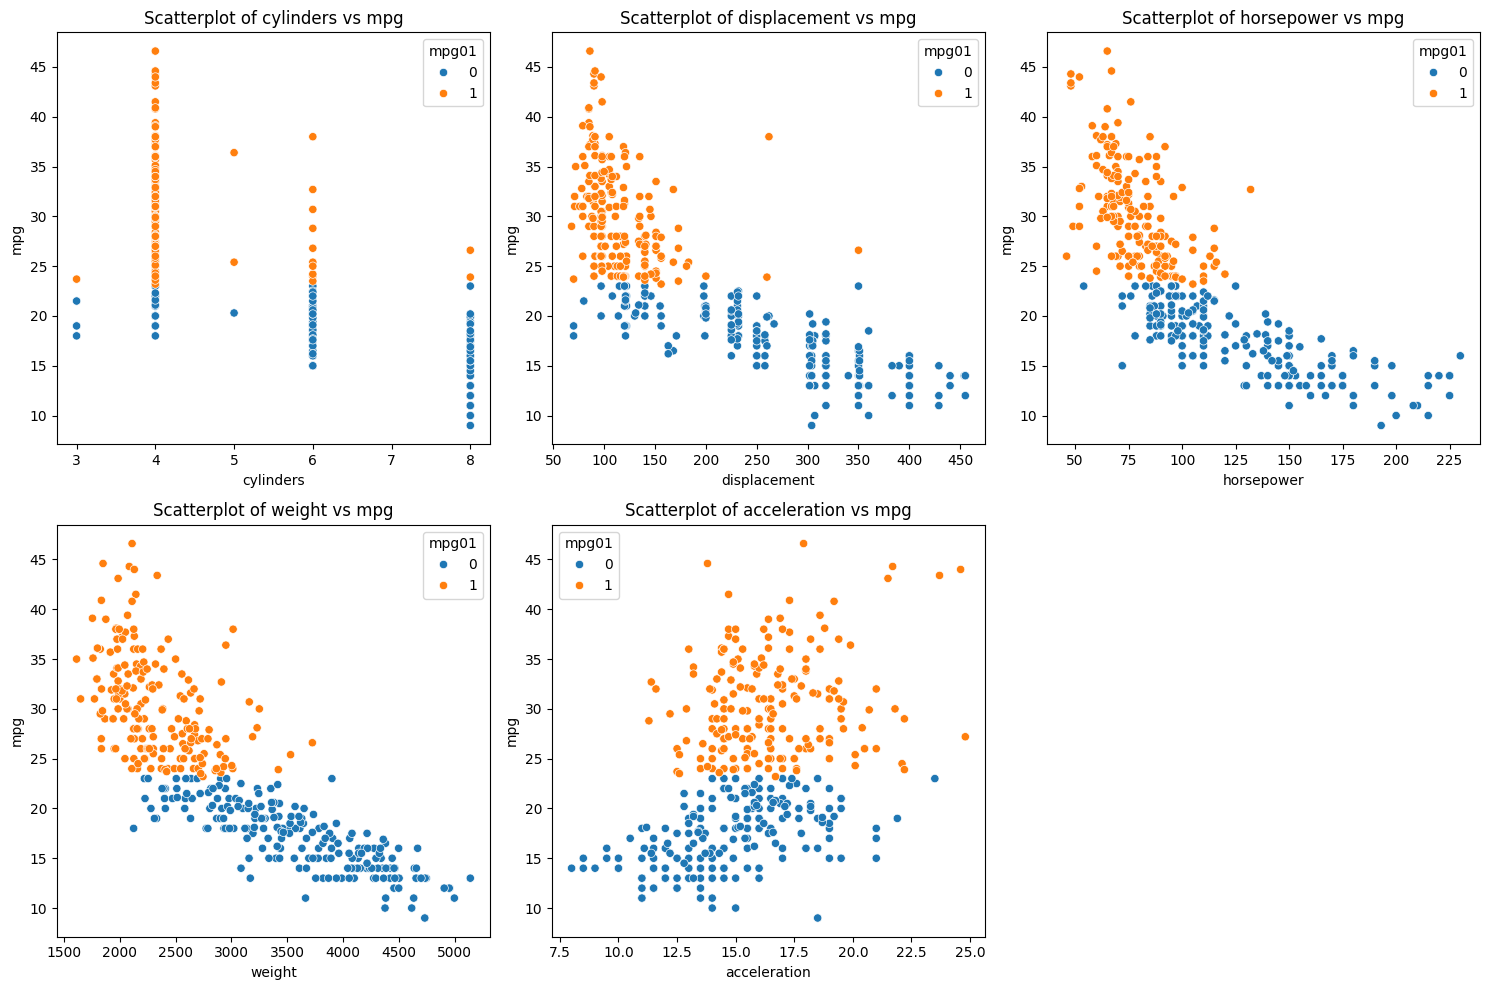

In [26]:
# Create scatterplots for each pair of features and mpg01
plt.figure(figsize=(15, 10))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(x=feature, y='mpg', hue='mpg01', data=auto)
    plt.title(f'Scatterplot of {feature} vs mpg')

plt.tight_layout()
plt.show()


Based on the provided plots and correlation table, here's an analysis for part (b):

Key Findings from Scatter Plots

Cylinders vs. mpg:

Observation: As the number of cylinders increases, mpg decreases.

Interpretation: More cylinders generally mean lower fuel efficiency.

Displacement vs. mpg:

Observation: Higher displacement correlates with lower mpg.

Interpretation: Larger engines consume more fuel.

Horsepower vs. mpg:

Observation: Higher horsepower is associated with lower mpg.

Interpretation: More powerful engines are less fuel-efficient.

Weight vs. mpg:

Observation: There is a clear negative correlation between weight and mpg.

Interpretation: Heavier vehicles are less efficient.

Acceleration vs. mpg:

Observation: The relationship is less pronounced but still visible.

Interpretation: Acceleration has a weaker correlation with mpg.

Key Findings from Box Plots

Cylinders, Displacement, Weight, Horsepower:

These features show clear differences between mpg01 categories, indicating strong associations with fuel efficiency.

Correlation Table Insights

Strong Negative Correlations:

Cylinders (-0.740), Displacement (-0.739), Weight (-0.746), Horsepower (-0.739) with mpg01.

These features are inversely related to mpg01, meaning higher values lead to lower fuel efficiency.

Moderate Positive Correlation:

Acceleration (0.323) has a weaker positive correlation with mpg01.

Conclusion
The features most strongly associated with mpg01 are cylinders, displacement, weight, and horsepower. These should be considered when predicting mpg01. Acceleration has a weaker relationship but could still provide some predictive value.


**(c) Split the data into a training set and a test set:**

In [28]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(auto, test_size=0.2, random_state=42)

#Here Selecting features that are most associated with mpg01
features = ['cylinders', 'displacement', 'horsepower', 'weight']

# Split the data into training and test sets
X = auto[features]
y = auto['mpg01']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the resulting datasets
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (317, 4)
Test set shape: (80, 4)


**(h) Perform KNN on the training data and evaluate test errors for different values of K:
To predict mpg01, we will perform K-Nearest Neighbors (KNN) using the selected features from part (b) and assess the model performance for various values of K**

In [31]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# Select features most associated with mpg01
features = ['cylinders', 'displacement', 'horsepower', 'weight']
X = auto[features]
y = auto['mpg01']

# Check for missing values
if X.isnull().sum().any():
    X = X.fillna(X.mean())  # Fill missing values with column mean

# Split the data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features (important for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize a list to store accuracies for each K value
accuracies = []
ks = range(1, 21)

# Perform KNN for different K values with 5-fold cross-validation
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    # Cross-validation to estimate accuracy on training data
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    accuracies.append(scores.mean())

# Find the best K value and its corresponding accuracy
best_k = ks[accuracies.index(max(accuracies))]
best_accuracy = max(accuracies)

# Print the best K and the corresponding cross-validated accuracy
print(f"Best K: {best_k}, Accuracy: {best_accuracy:.4f}")

Best K: 5, Accuracy: 0.9055


**Run PCA on the auto dataset using the features: cylinders, displacement, horsepower, weight, and acceleration . Rescale the above variables using StandardScaler and apply PCA again. What differences do you notice between the two PCA runs?**

<ipython-input-34-dbc879259af7>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  auto['horsepower'].fillna(auto['horsepower'].mean(), inplace=True)


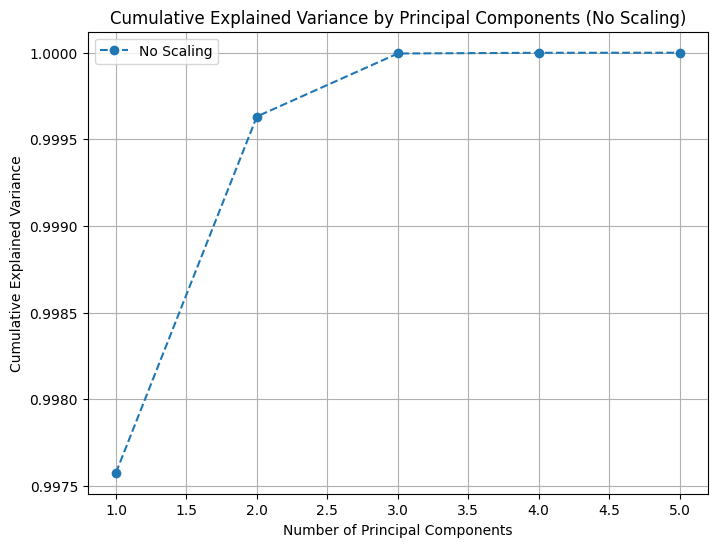

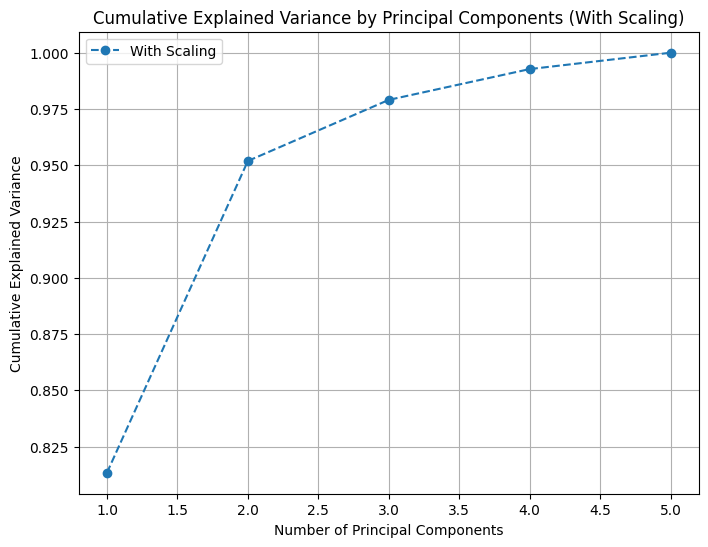

In [34]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Fill NaN values in 'horsepower' with the mean
auto['horsepower'].fillna(auto['horsepower'].mean(), inplace=True)

# Select features for PCA
features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']
X = auto[features]

# Step 1: Apply PCA without scaling the data
pca_no_scaling = PCA()
X_pca_no_scaling = pca_no_scaling.fit_transform(X)

# Plot the explained variance ratio for PCA without scaling
explained_variance_no_scaling = pca_no_scaling.explained_variance_ratio_
cumulative_variance_no_scaling = explained_variance_no_scaling.cumsum()

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance_no_scaling) + 1), cumulative_variance_no_scaling, marker='o', linestyle='--', label='No Scaling')
plt.title('Cumulative Explained Variance by Principal Components (No Scaling)')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.legend()
plt.show()

# Step 2: Rescale the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA with scaled data
pca_with_scaling = PCA()
X_pca_with_scaling = pca_with_scaling.fit_transform(X_scaled)

# Plot the explained variance ratio for PCA with scaling
explained_variance_with_scaling = pca_with_scaling.explained_variance_ratio_
cumulative_variance_with_scaling = explained_variance_with_scaling.cumsum()

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance_with_scaling) + 1), cumulative_variance_with_scaling, marker='o', linestyle='--', label='With Scaling')
plt.title('Cumulative Explained Variance by Principal Components (With Scaling)')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.legend()
plt.show()

Based on the PCA graphs , here are the differences observed between the two PCA runs:

### Without Scaling

- **Variance Concentration**: The first principal component explains almost all of the variance. This suggests that one or a few features with larger scales dominate the analysis.
- **Cumulative Variance**: Nearly 100% of the variance is captured by just one or two components, indicating an imbalance due to unscaled data.

### With Scaling

- **Balanced Variance Distribution**: The variance is more evenly distributed across multiple components. This shows that each feature contributes more equally to the variance.
- **Cumulative Variance**: It takes more components to reach a similar level of cumulative variance compared to the unscaled version, reflecting a more balanced representation of all features.

### Conclusion

Scaling ensures that no single feature disproportionately influences the PCA results, leading to a more accurate and balanced understanding of the data's structure.